# Hydrometeorological Reconstruction Through Basin Morphometric Characterization and Autoregressive Precipitation Modeling: Linking Static Form and Dynamic Signals

> **Authors:** [Cazares-Duran, J.J., Aguilar-Ojeda, J. A., J. Kretzschmar, T.]

> **Year:** [2026]

> **Journal:** [Applied Computing and Geosciences] *(under review)*

---

This notebook contains the methodological workflow applied to analyze and impute hydrometeorological time series, developed as supplementary material 
for the manuscript under review.

**Python version:** 3.10.19 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 16:41:31) [MSC v.1929 64 bit (AMD64)]

---

ARIMA (AutoRegressive Integrated Moving Average) and SARIMAX (Seasonal AutoRegressive Integrated Moving Average with eXogenous variables) are 
linear time-series models that characterize temporal structure through three components: autoregressive dependence (AR), differencing for 
stationarity (I), and moving average error correction (MA). SARIMAX extends this framework by incorporating seasonal periodicity (S) and exogenous covariates (X), making it suitable for hydrometeorological series where both cyclical patterns and external forcing variables are relevant.

#### Main dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import warnings
import itertools
import os
import contextily as cx

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.tools.sm_exceptions import ValueWarning
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose

from astropy.timeseries import LombScargle
from scipy.interpolate import RBFInterpolator
from shapely.geometry import Point

---
## 1. Study Area: Rain Gauge Structure and Station Network Visualization

Data structure and spatial visualization of the rain gauge station network used in the analysis. Stations are plotted over a topographic basemap to provide geographic context for the study area.

> **Data source:** `Rain_gauges_mm.csv`  
> **Coordinate system:** WGS84 (EPSG:4326), reprojected to Web Mercator (EPSG:3857) for visualization  
> **Period of analysis:** 1980–2020

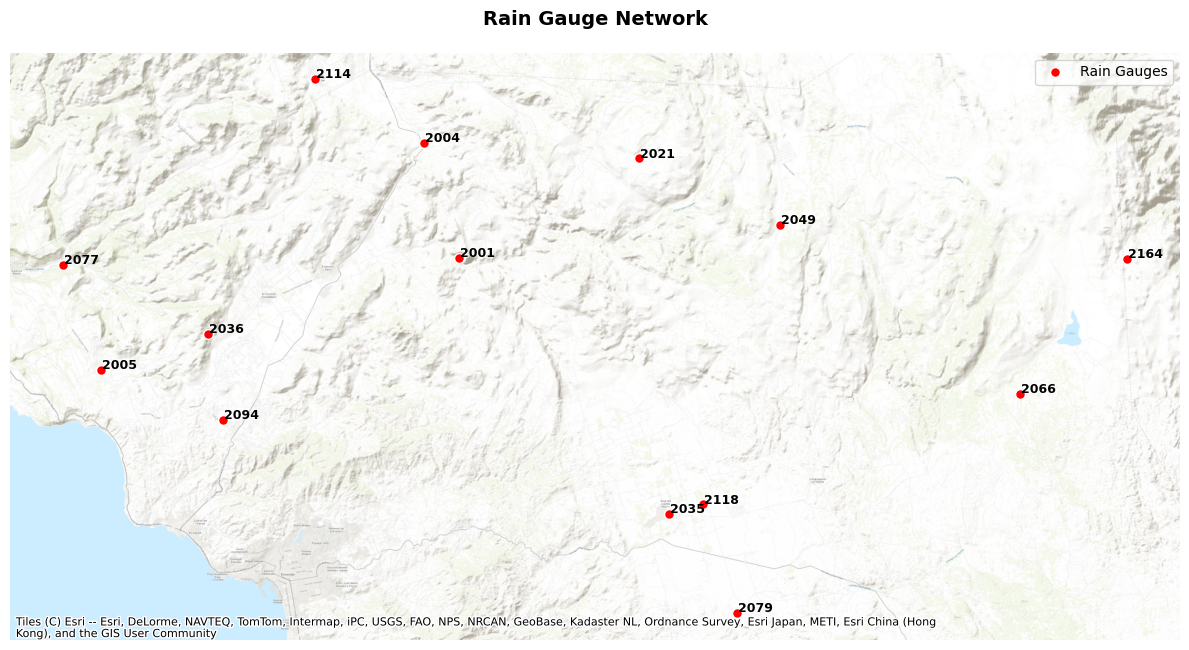

In [2]:
df = pd.read_csv('Rain_gauges_mm.csv')
df_inrange = df[(df['Year'] >= 1980) & (df['Year'] <= 2020)]
df_map = df_inrange[['Station', 'Lat', 'Lon']].drop_duplicates()

geometry = [Point(xy) for xy in zip(df_map['Lon'], df_map['Lat'])]
gdf = gpd.GeoDataFrame(df_map, geometry=geometry, crs="EPSG:4326")
gdf = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 10))

gdf.plot(ax=ax, color='red', markersize=50, edgecolor='white', linewidth=1, zorder=5, label='Rain Gauges')

for x, y, label in zip(gdf.geometry.x, gdf.geometry.y, gdf['Station']):
    ax.text(x + 100, y + 100, str(label), fontsize=9, fontweight='bold', zorder=6)

cx.add_basemap(ax, source=cx.providers.Esri.WorldTopoMap, zoom=13)

ax.set_title('Rain Gauge Network', fontsize=14, pad=20, fontweight='bold')
ax.set_axis_off() 
plt.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

## 2. Construction and Visualization of Monthly Precipitation Time Series

Monthly precipitation records were transformed into continuous time series for each rain gauge station. The original dataset, stored in wide format (`Year × Month`), was reshaped into a long-format structure to facilitate temporal indexing and subsequent time-series analysis.

A monthly datetime index was generated for the period 1980–2020, and each station series was reindexed to a complete monthly range (`MS` frequency). Missing periods were preserved as `NaN` values to maintain temporal continuity and enable later imputation using SARIMAX models.

The resulting series were plotted individually to visually inspect:
- seasonal precipitation patterns,
- temporal continuity,
- anomalous values, and
- the distribution of missing observations.

> **Input data:** Monthly precipitation records by station  
> **Temporal resolution:** Monthly  
> **Study period:** January 1980 – December 2020  
> **Output:** Continuous monthly precipitation time series per station

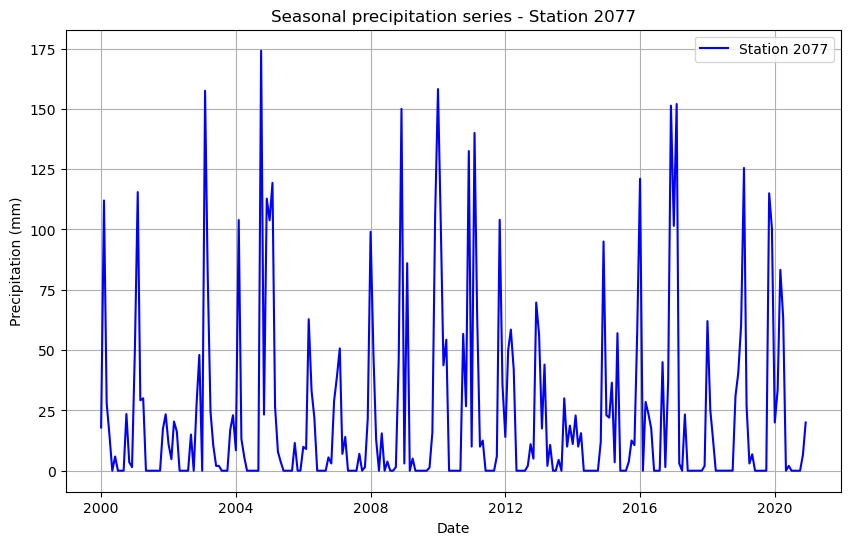

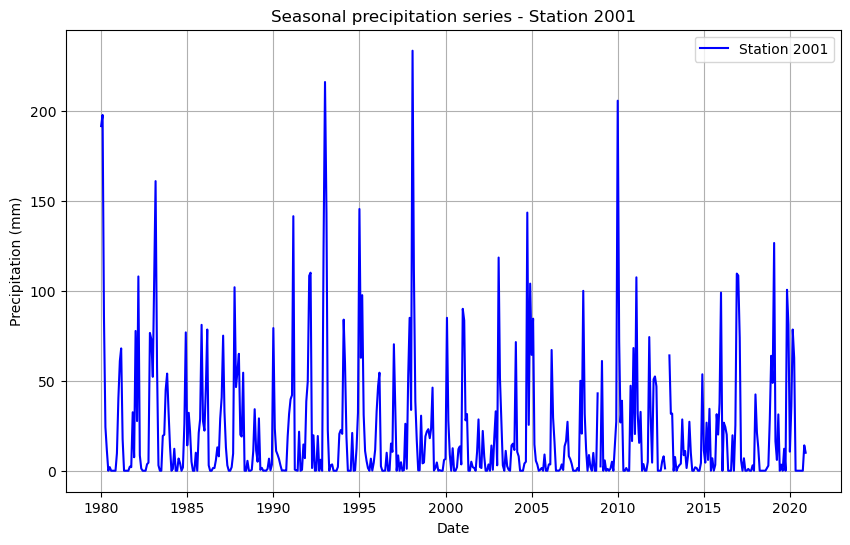

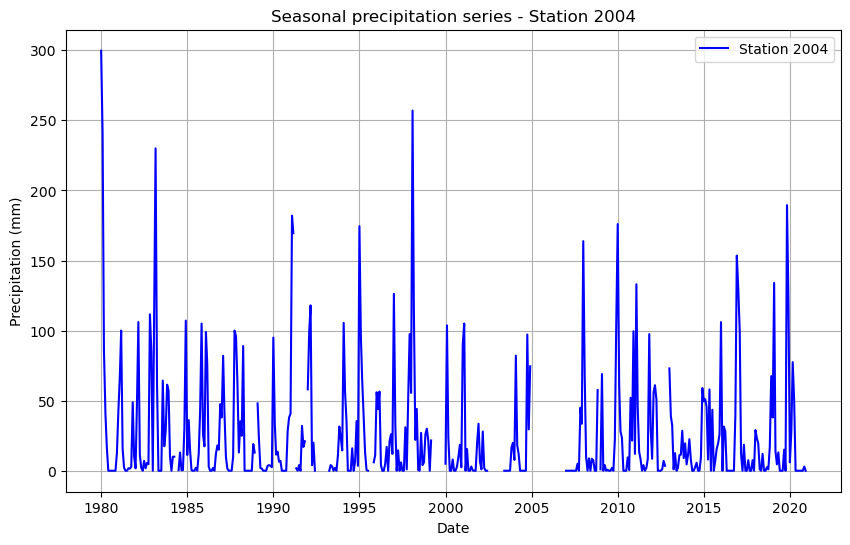

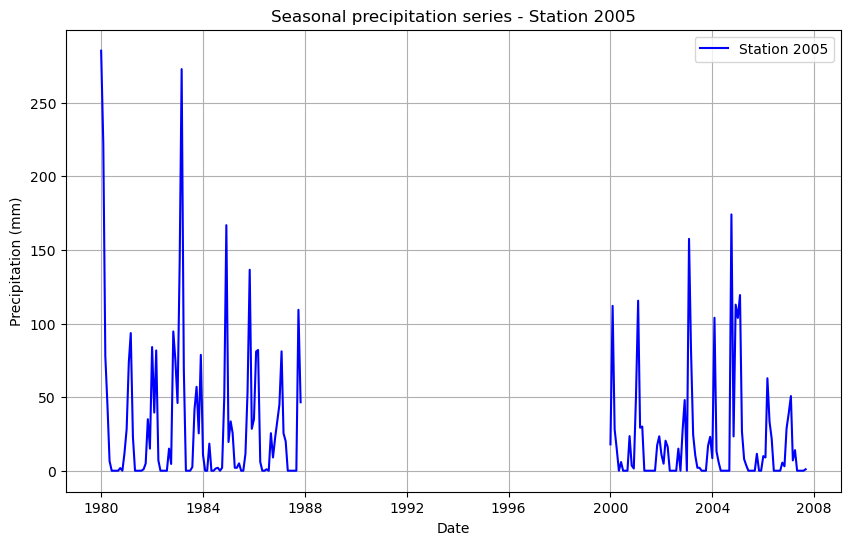

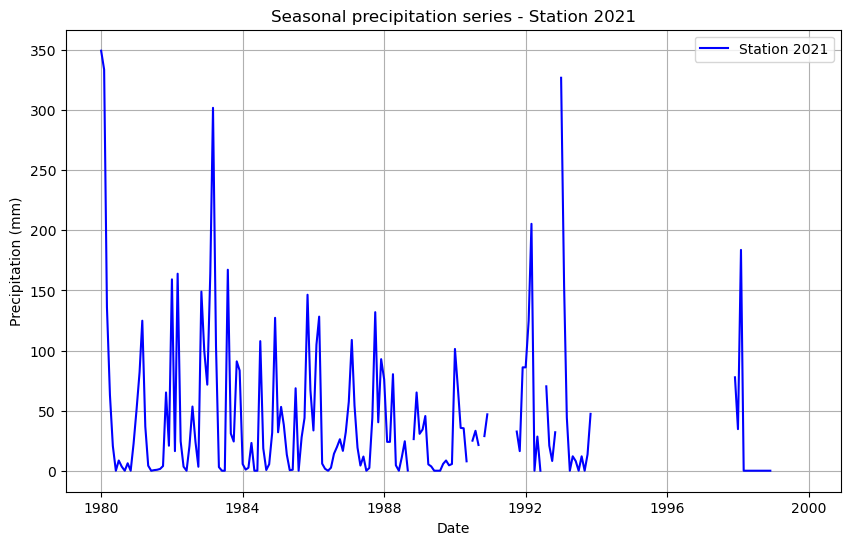

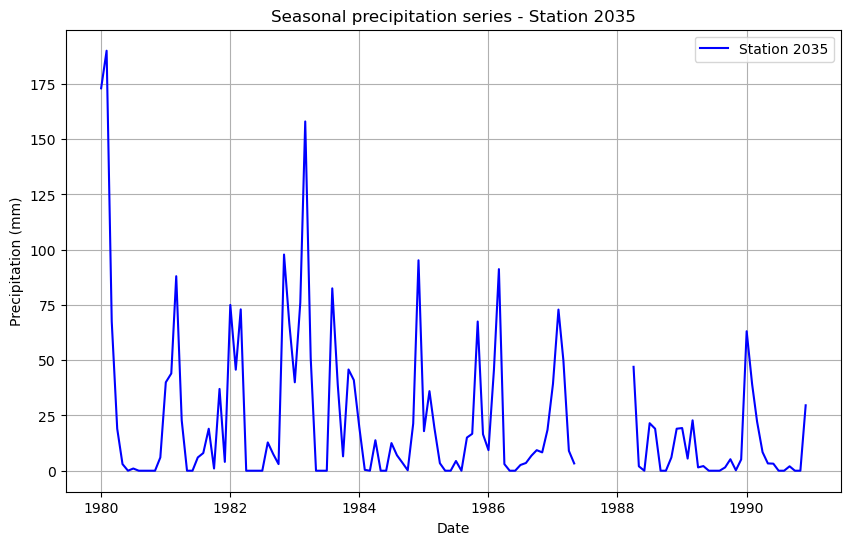

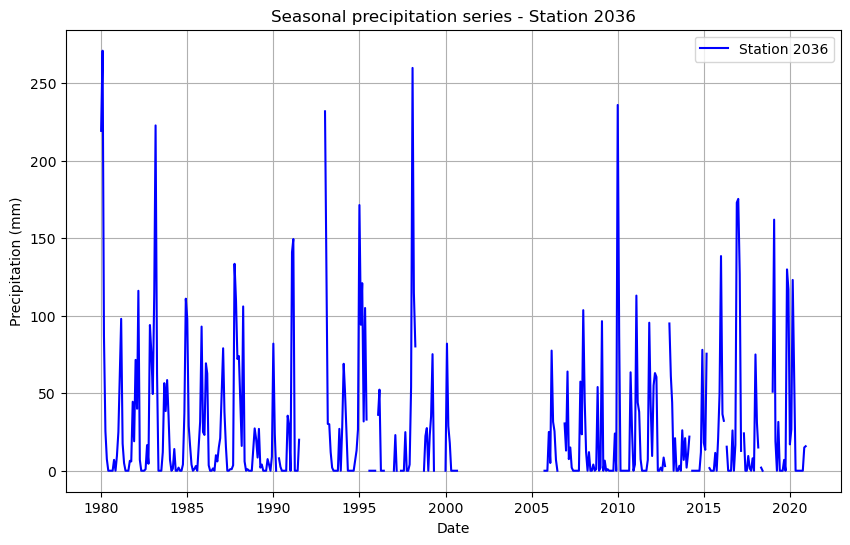

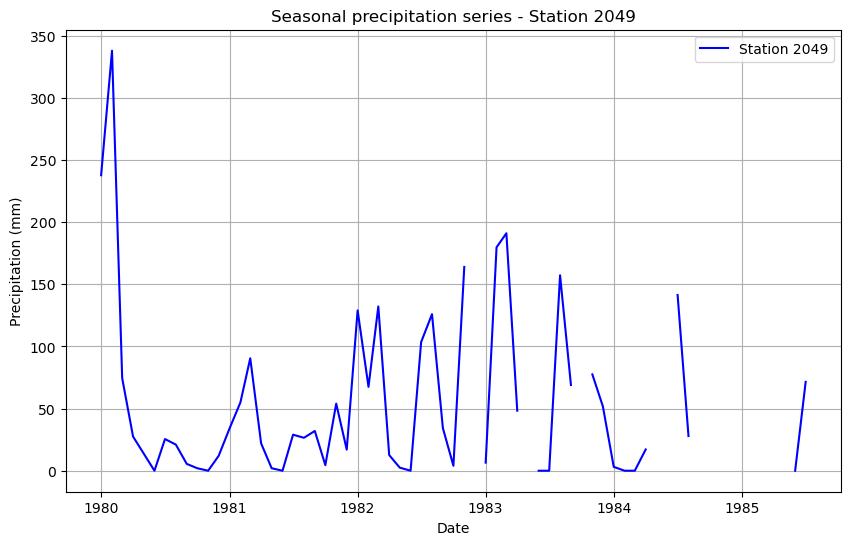

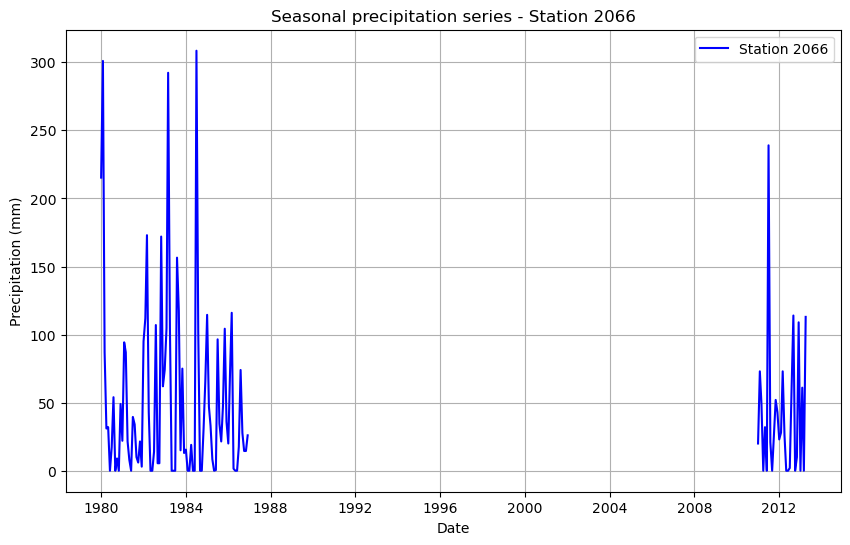

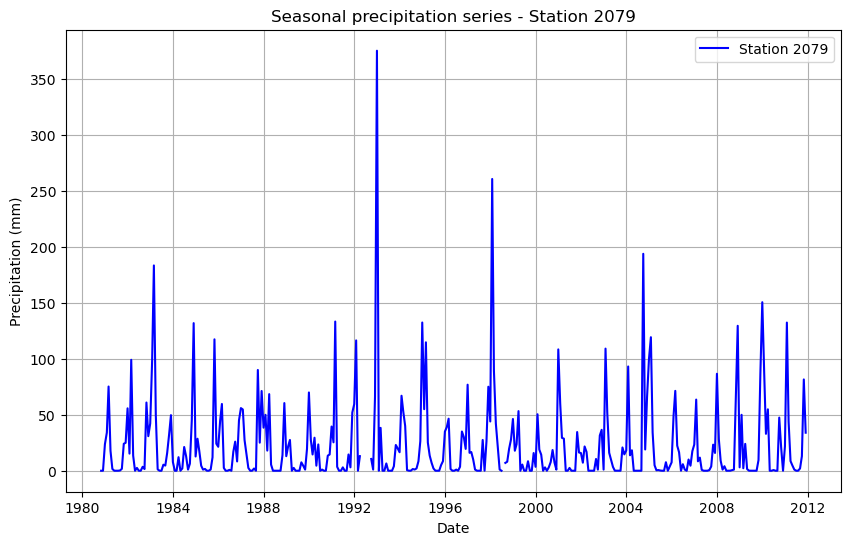

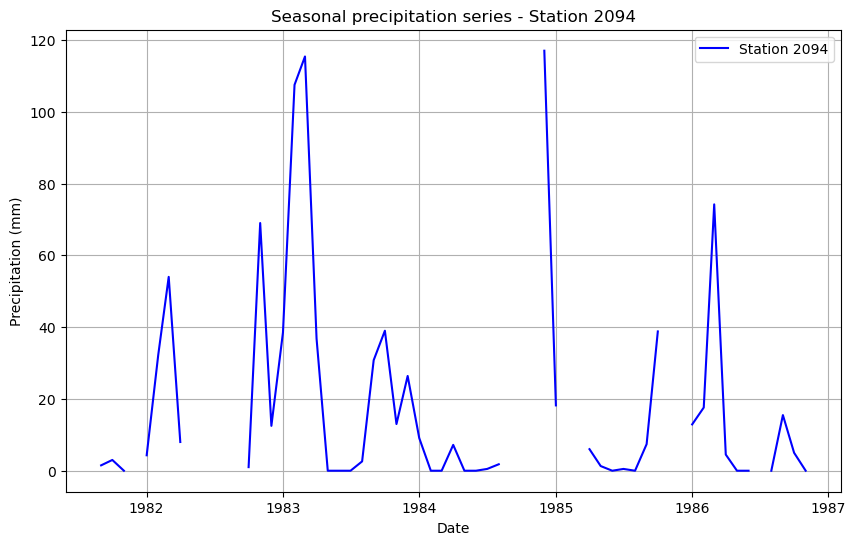

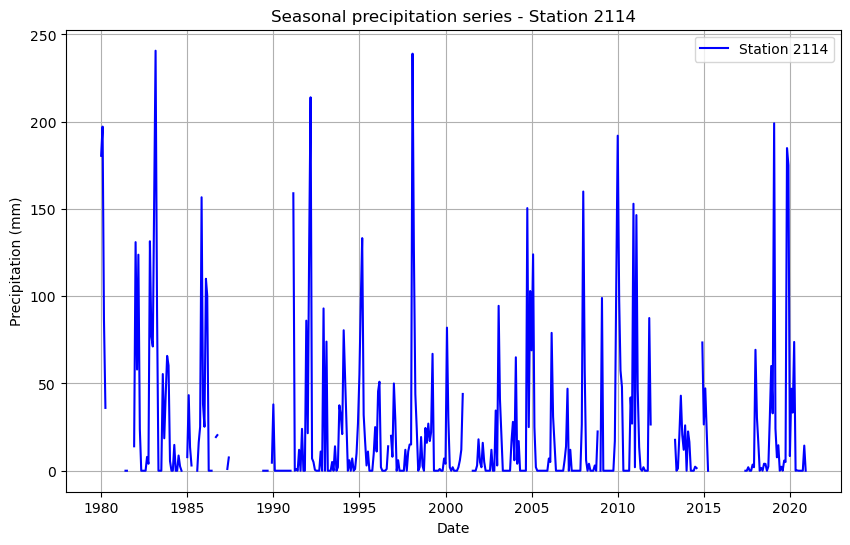

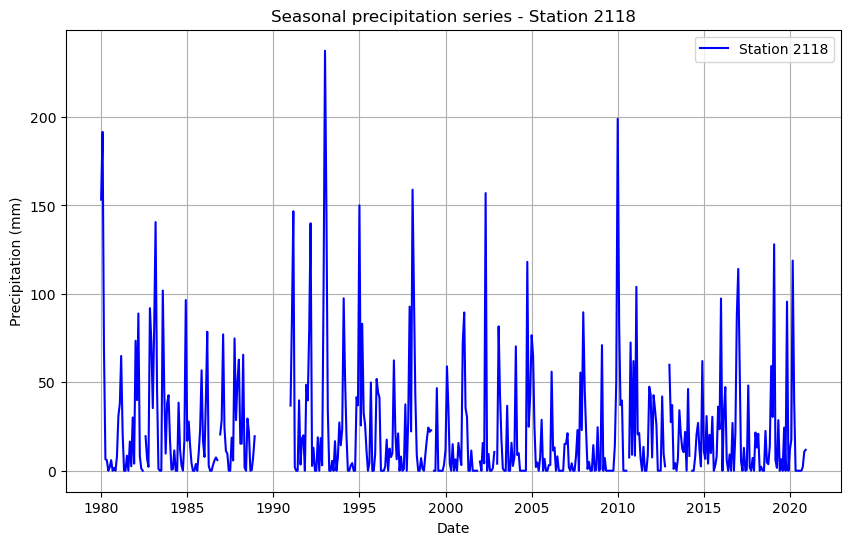

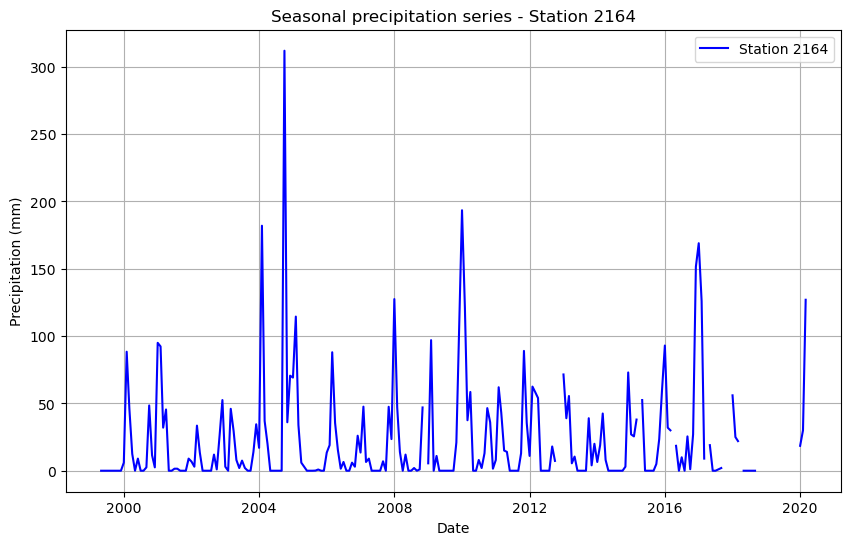

In [3]:
series = {}

for station in df_inrange['Station'].unique():
    data = df_inrange[df_inrange['Station'] == station]
    data = data.set_index('Year')
    data_long = data.reset_index().melt(id_vars='Year', var_name='MONTH', value_name='PRECIPITATION')
    
    month_map = {
        'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4,
        'May': 5, 'Jun': 6, 'Jul': 7, 'Aug': 8,
        'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
    }
    
    data_long['MONTH_NUM'] = data_long['MONTH'].map(month_map)
    data_long['DATE'] = pd.to_datetime(dict(year=data_long['Year'], month=data_long['MONTH_NUM'], day=1))
    data_long = data_long.sort_values('DATE')

    serie = data_long.groupby('DATE')['PRECIPITATION'].mean()

    full_range = pd.date_range(start='1980-01-01', end='2020-12-01', freq='MS')
    serie = serie.reindex(full_range)

    series[station] = serie

for station, serie in series.items():
    plt.figure(figsize=(10, 6))
    plt.plot(serie.index, serie.values, label=f'Station {station}', color='blue')
    plt.title(f'Seasonal precipitation series - Station {station}')
    plt.xlabel('Date')
    plt.ylabel('Precipitation (mm)')
    plt.legend()
    plt.grid()
    plt.show()

## 3. ENSO Climate Index Preprocessing and Temporal Visualization

The El Niño–Southern Oscillation (ENSO 3.4) climate index was incorporated as an exogenous climatic covariate to evaluate its potential influence on regional precipitation variability and to support SARIMAX-based imputation.

The ENSO dataset was imported and reformatted into a standardized monthly time series. Date fields were converted to `datetime` format, chronologically ordered, and indexed at monthly start frequency (`MS`) to ensure temporal consistency with the precipitation records.

The processed ENSO anomaly series was then visualized to inspect:
- interannual climate variability,
- warm and cold ENSO phases (El Niño and La Niña),
- long-term temporal coherence, and
- compatibility with the precipitation study period.

> **Climate index:** ENSO sea surface temperature anomaly  
> **Temporal resolution:** Monthly  
> **Study period:** 1980–2020  
> **Purpose:** External regressor for SARIMAX precipitation imputation

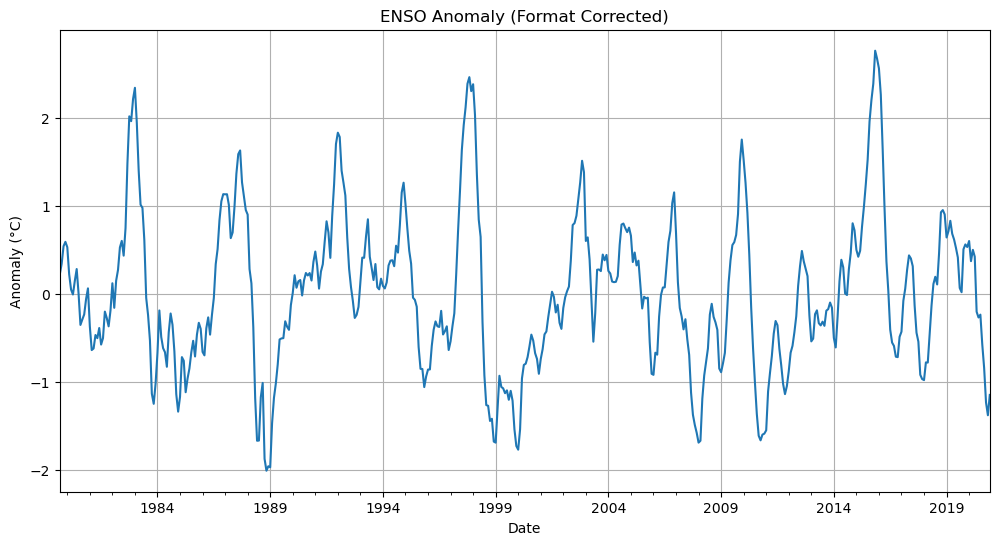

In [4]:
ENSO = pd.read_csv("ENSO_1980_2020.csv")
ENSO['Date'] = pd.to_datetime(ENSO['Date'], dayfirst=True)
ENSO.set_index('Date', inplace=True)
ENSO.sort_index(inplace=True)
ENSO = ENSO.asfreq('MS')
ENSO_series = ENSO['ENSO']
ENSO_series.plot(figsize=(12, 6), title='ENSO Anomaly (Format Corrected)')
plt.xlabel('Date')
plt.ylabel('Anomaly (°C)')
plt.grid(True)
plt.show()

## 4. ENSO–Precipitation Lag Correlation Analysis

Lagged cross-correlation analysis was performed between ENSO anomalies and station precipitation anomalies to identify the most relevant temporal delay for incorporating ENSO as an exogenous predictor in the SARIMAX models.

To isolate interannual variability, monthly anomalies were computed for both precipitation and ENSO by removing the long-term monthly climatology, thereby reducing the influence of the seasonal cycle.

Pearson correlation coefficients were evaluated for temporal lags ranging from 0 to 6 months, representing the delayed atmospheric and oceanic teleconnection effects commonly associated with ENSO-driven precipitation responses.

For each station, the optimal lag was defined as the lag producing the maximum absolute correlation coefficient.

Stations with fewer than 24 valid overlapping observations were excluded to avoid unstable correlation estimates. A significance threshold of α = 0.10 was adopted due to the reduced effective sample size caused by discontinuous precipitation records.

> **Method:** Lagged Pearson cross-correlation  
> **Lag range evaluated:** 0–6 months  
> **Significance threshold:** α = 0.10  
> **Purpose:** Selection of optimal ENSO lag for SARIMAX exogenous forcing

In [5]:
ENSO_anom = ENSO.copy()
ENSO_anom['month'] = ENSO_anom.index.month
ENSO_anom['ENSO_anom'] = (
    ENSO_anom.groupby('month').transform(lambda x: x - x.mean())
)
ENSO_anom = ENSO_anom['ENSO_anom']
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, t

def analyze_enso_robust(series_dict, enso_anom, max_lag=6, min_months=24):
    final_results = []
    
    for station, serie in series_dict.items():
        serie = serie.dropna().asfreq('MS')
        if len(serie) < min_months: continue
        
        df_st = pd.DataFrame({'P': serie})
        df_st['month'] = df_st.index.month
        df_st['P_anom'] = df_st.groupby('month')['P'].transform(lambda x: x - x.mean())
        
        common = pd.concat([df_st['P_anom'], enso_anom], axis=1).dropna()
        
        if len(common) < min_months:
            continue

        best_r, best_lag, best_p = 0, 0, 1
        
        for lag in range(max_lag + 1):
            y = common['P_anom'].values
            x = common['ENSO_anom'].shift(lag).values
            
            mask = np.isfinite(x) & np.isfinite(y)
            if mask.sum() < min_months: continue
            
            r, p = pearsonr(x[mask], y[mask]) 
            
            if abs(r) > abs(best_r):
                best_r, best_lag, best_p = r, lag, p

        final_results.append({
            'Station': station,
            'Lag': best_lag,
            'r': round(best_r, 3),
            'p_value': round(best_p, 4),
            'Months': len(common),
            'Sig_90': best_p < 0.10 
        })

    return pd.DataFrame(final_results).sort_values('r', ascending=False)

df_diag_v2 = analyze_enso_robust(series, ENSO_anom)
display(df_diag_v2)

,Station,Lag,r,p_value,Months,Sig_90
5,2035,3,0.470,0.0000,122,True
10,2094,3,0.443,0.0020,49,True
7,2049,3,0.391,0.0041,55,True
3,2005,2,0.296,0.0000,188,True
4,2021,2,0.295,0.0001,172,True
11,2114,2,0.279,0.0000,385,True
6,2036,2,0.279,0.0000,375,True
1,2001,2,0.271,0.0000,489,True
2,2004,2,0.262,0.0000,429,True
8,2066,2,0.261,0.0059,112,True


## 5. SARIMAX Optimal Parameter Selection

Grid search over the SARIMA(p,d,q)(P,D,Q)s parameter space encapsulated 
in `sarimax_grid_search()`. The function evaluates all parameter 
combinations per station, logs non-converged or failed models separately, 
and returns the optimal configuration based on combined AIC and BIC ranking.

Fixed parameters: d=1, D=1, s=12 (monthly seasonality), consistent with 
the stationarity and seasonality diagnostics from Section 3. ENSO index 
is included as exogenous variable based on the optimal lag identified 
in Section 5. Convergence warnings are expected for stations with limited 
observations and are discussed in the manuscript results.

**Output:**
- `df_optimal` — optimal SARIMAX configuration per station
- `df_failed` — log of non-converged or failed model combinations

In [6]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.simplefilter("ignore", ValueWarning)
warnings.simplefilter("ignore", UserWarning)

def sarimax_grid_search(series, enso_series, p=[0,1], q=[0,1], P=[0,1], Q=[0,1], d=1, D=1, s=12, min_obs=24):
    
    orders = list(itertools.product(p, [d], q))
    seasonal_orders = list(itertools.product(P, [D], Q, [s]))
    
    results = []
    failed_models = []
    
    for station, serie in series.items():
        serie = serie.asfreq('MS')
        enso = enso_series.reindex(serie.index)
        df = pd.concat([serie.rename('y'), enso.rename('ENSO')], axis=1).dropna()
        
        if len(df) < min_obs:
            continue
        
        for order in orders:
            for sorder in seasonal_orders:
                try:
                    mod = SARIMAX(
                        df['y'],
                        exog=df[['ENSO']],
                        order=order,
                        seasonal_order=sorder,
                        enforce_stationarity=False,
                        enforce_invertibility=False
                    )
                    res = mod.fit(disp=False)
                    lb_pvalue = acorr_ljungbox(
                        res.resid, lags=[12], return_df=True
                    )['lb_pvalue'].iloc[0]
                    
                    results.append({
                        'Station': station,
                        'order': order,
                        'seasonal_order': sorder,
                        'AIC': res.aic,
                        'BIC': res.bic,
                        'LB_pvalue_12': lb_pvalue
                    })
                    
                except Exception as e:
                    failed_models.append({
                        'Station': station,
                        'order': order,
                        'seasonal_order': sorder,
                        'error': str(e)
                    })
                    continue
    
    df_results = pd.DataFrame(results)
    df_results['rank_AIC'] = df_results.groupby('Station')['AIC'].rank()
    df_results['rank_BIC'] = df_results.groupby('Station')['BIC'].rank()
    df_results['rank_mean'] = (df_results['rank_AIC'] + df_results['rank_BIC']) / 2
    
    df_optimal = (
        df_results.sort_values(['Station', 'rank_mean'])
                  .groupby('Station')
                  .head(1)
                  .reset_index(drop=True)
    )
    
    df_failed = pd.DataFrame(failed_models)
    print(f"Optimal models detected: {len(df_optimal)}")
    print(f"Failed or non-converged models: {len(df_failed)}")
    
    return df_optimal, df_failed


df_optimal, df_failed = sarimax_grid_search(series, ENSO_series)
display(df_optimal)
display(df_failed)

Optimal models detected: 14
Failed or non-converged models: 0


,Station,order,seasonal_order,AIC,BIC,LB_pvalue_12,rank_AIC,rank_BIC,rank_mean
0,2001,"(1, 1, 1)","(0, 1, 1, 12)",4443.433386,4464.111210,0.857786,1.0,1.0,1.0
1,2004,"(1, 1, 1)","(0, 1, 1, 12)",4048.874194,4068.856454,0.108815,2.0,1.0,1.5
2,2005,"(1, 1, 1)","(0, 1, 1, 12)",1639.873171,1655.280193,0.080742,1.0,1.0,1.0
3,2021,"(1, 1, 1)","(0, 1, 1, 12)",1575.275250,1590.158919,0.218087,1.0,1.0,1.0
4,2035,"(1, 1, 1)","(0, 1, 1, 12)",899.482896,912.252281,0.110306,1.0,1.0,1.0
5,2036,"(1, 1, 1)","(0, 1, 1, 12)",3593.290176,3612.551189,0.149503,2.0,1.0,1.5
6,2049,"(1, 1, 1)","(1, 1, 0, 12)",337.341901,344.178380,0.094002,1.0,1.0,1.0
7,2066,"(0, 1, 1)","(0, 1, 1, 12)",960.716025,970.486630,0.726517,2.0,1.0,1.5
8,2077,"(0, 1, 1)","(0, 1, 1, 12)",2218.751959,2232.416360,0.381851,2.0,1.0,1.5
9,2079,"(1, 1, 1)","(0, 1, 1, 12)",3461.480082,3480.639495,0.229247,1.0,1.0,1.0


""


## 6. SARIMAX-Based Imputation of Monthly Precipitation Records

Monthly precipitation series were reconstructed and standardized to a continuous monthly-start (`MS`) temporal frequency using a complete datetime index. Missing observations were subsequently imputed using Seasonal AutoRegressive Integrated Moving Average models with exogenous climatic forcing (SARIMAX), incorporating the ENSO index as an external predictor.

For each rain gauge station, optimal SARIMA configurations were previously determined through grid-search optimization using Akaike Information Criterion (AIC) and Bayesian Information Criterion (BIC). These station-specific model structures were then applied for temporal gap reconstruction.

In stations affected by late observational onset or pronounced edge effects, temporal inversion (backcasting) was applied prior to model fitting. Under this approach, both the precipitation series and the ENSO predictor were reversed chronologically, enabling the model to estimate earlier missing conditions using information from more recent observations. Predicted values were subsequently restored to their original chronological order.

To preserve physical consistency, negative precipitation estimates were constrained to zero. Imputed values replaced only missing observations, while all original recorded measurements were retained unchanged.

The resulting datasets consist of continuous monthly precipitation series suitable for subsequent climatological, hydroclimatic, and statistical analyses.

> **Method:** SARIMAX temporal imputation  
> **External predictor:** ENSO anomaly index  
> **Optimization criteria:** AIC and BIC  
> **Output:** Continuous monthly precipitation time series (1980–2020)


--- Processing 2077 ---
  -> Temporal Inversion


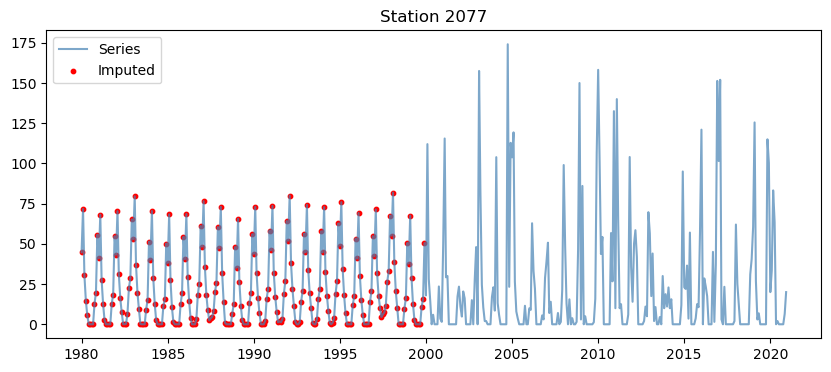


--- Processing 2001 ---


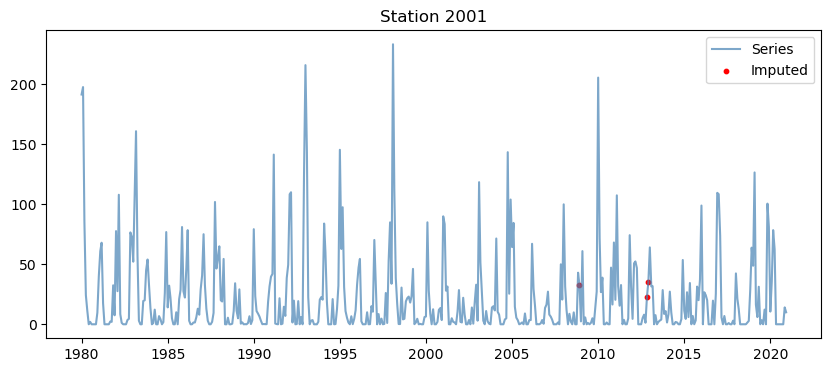


--- Processing 2004 ---


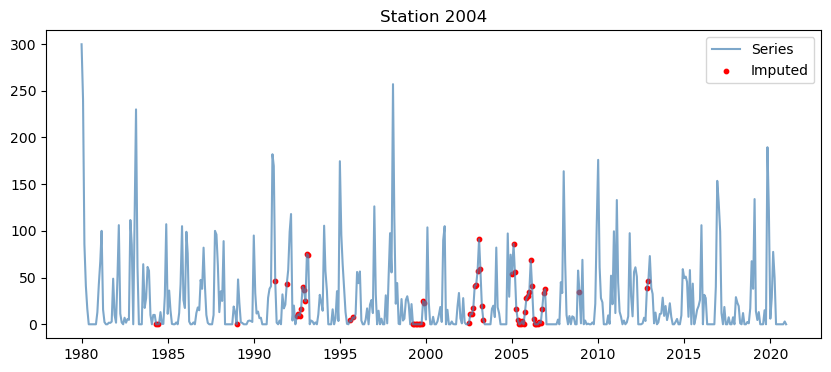


--- Processing 2005 ---


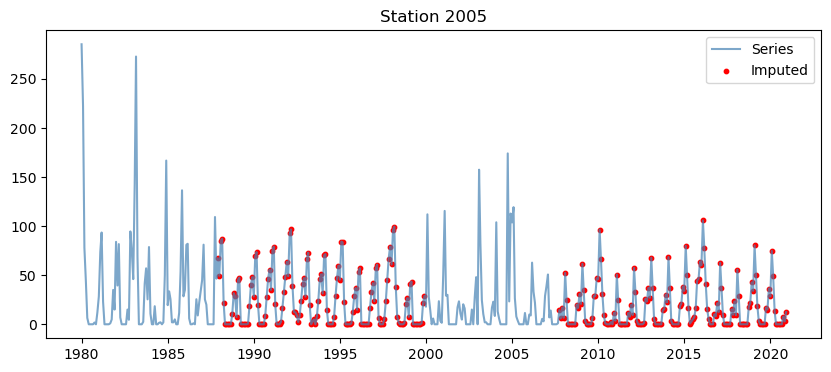


--- Processing 2021 ---


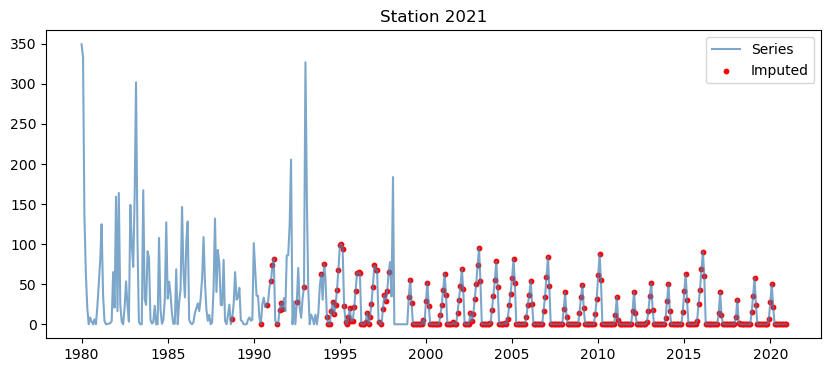


--- Processing 2035 ---


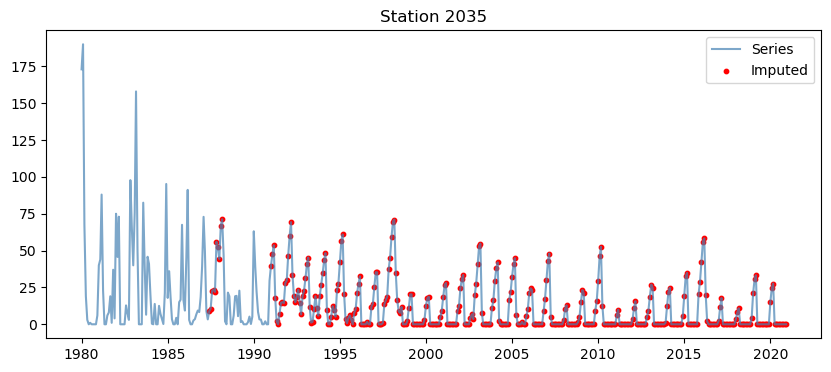


--- Processing 2036 ---


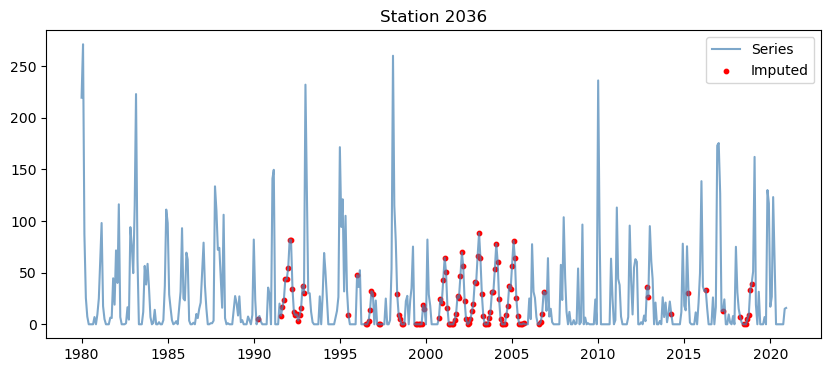


--- Processing 2049 ---


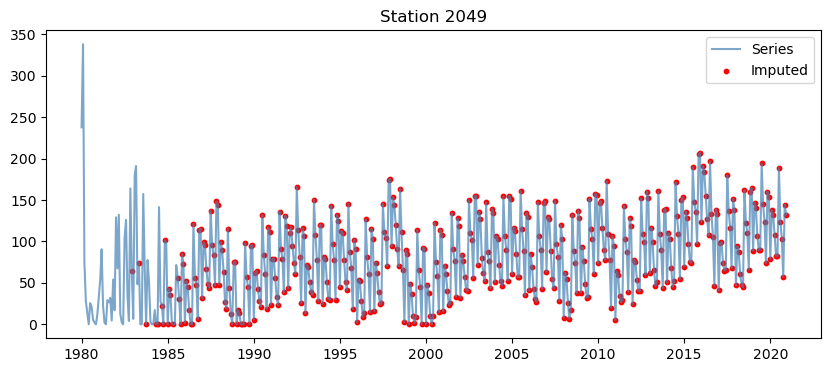


--- Processing 2066 ---


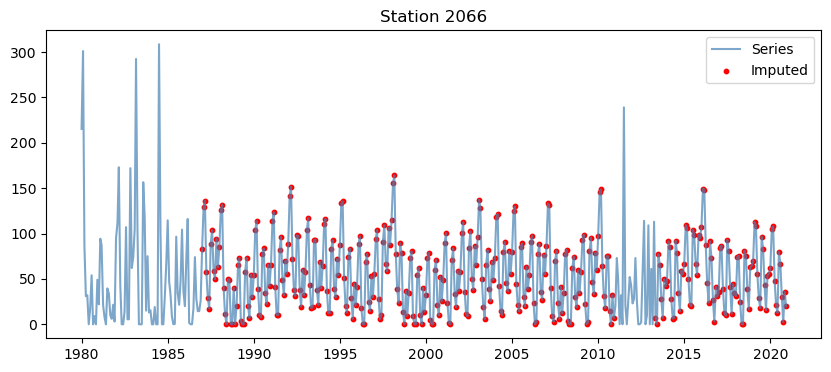


--- Processing 2079 ---


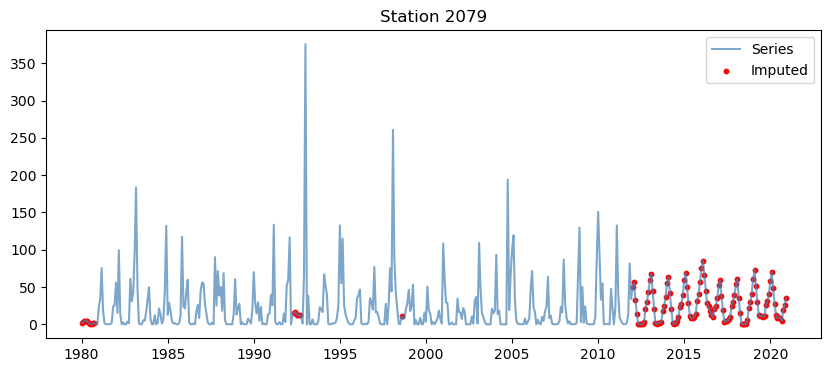


--- Processing 2094 ---


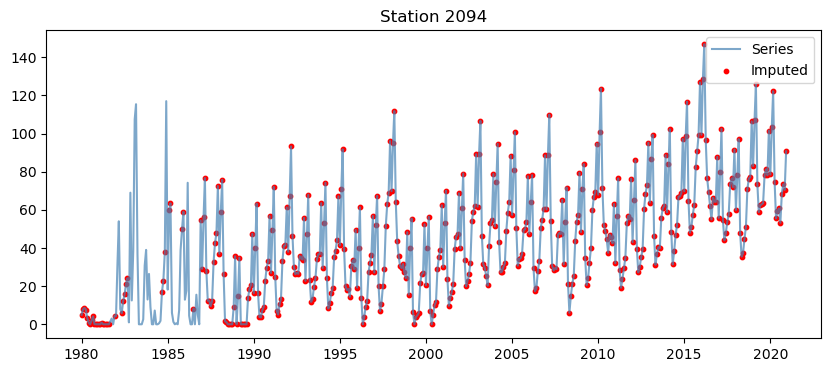


--- Processing 2114 ---


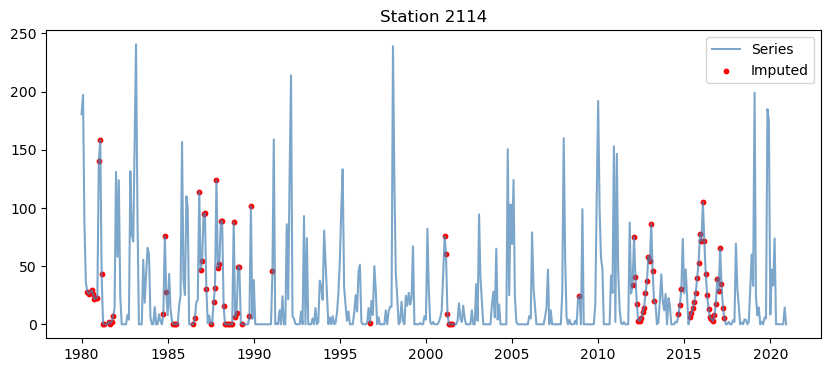


--- Processing 2118 ---


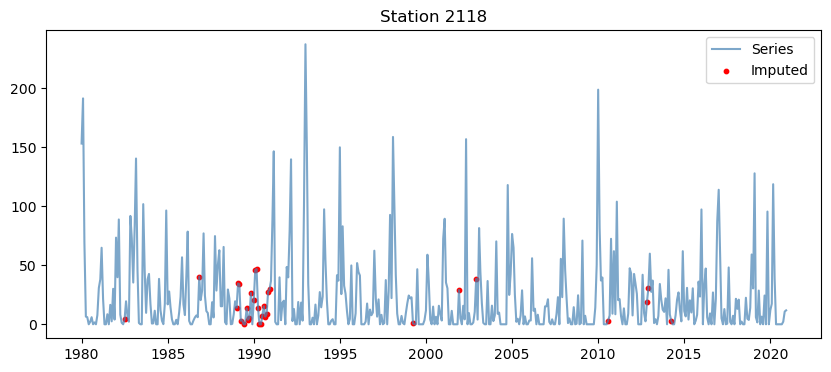


--- Processing 2164 ---
  -> Temporal Inversion


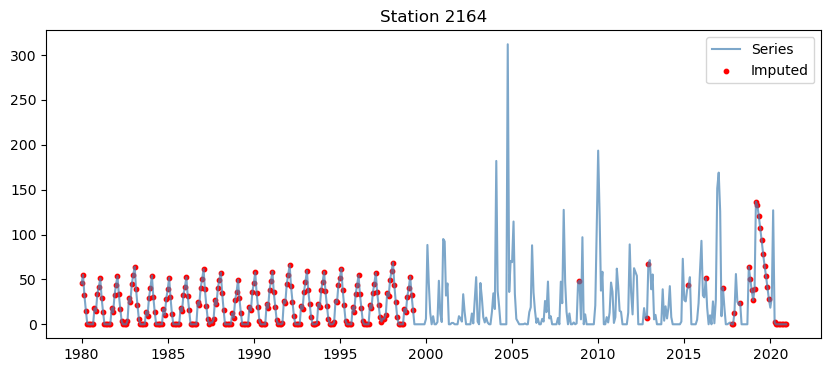


¡Saved as'Gualadupe_River_Basin_Imputed_Final.csv'


In [7]:
warnings.filterwarnings("ignore")
full_range = pd.date_range(start='1980-01-01', end='2020-12-01', freq='MS')
final_results = []
reverse_stations = [2077, 2164]

for station, serie in series.items():
    print(f"\n--- Processing {station} ---")
    
    row = df_optimal[df_optimal['Station'] == station].iloc[0]
    curr_order = row['order']
    curr_sorder = row['seasonal_order']
    curr_lag = df_diag_v2.loc[
        df_diag_v2['Station'] == station,
        'Lag'
    ].iloc[0]
    serie = serie.asfreq('MS')
    enso_total = ENSO_series.shift(curr_lag).asfreq('MS')
    
    reverse = (station in reverse_stations) or (serie.first_valid_index() > full_range[24])
    
    if reverse:
        print(f"  -> Temporal Inversion")
        y_train = serie[::-1]
        x_train = enso_total[::-1].reindex(y_train.index)
    else:
        y_train = serie
        x_train = enso_total.reindex(y_train.index)

    try:
        model = SARIMAX(
            y_train,
            exog=x_train,
            order=curr_order,
            seasonal_order=curr_sorder,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        result = model.fit(disp=False, maxiter=200)
        pred_mean = result.predict(
            exog=enso_total.reindex(y_train.index)
        )
        
        if reverse:
            pred_mean = pred_mean.sort_index()

        pred_mean[pred_mean < 0] = 0
        
        full_series = serie.reindex(full_range)
        mask_imputed = full_series.isna()
        
        final_series = full_series.copy()
        final_series[mask_imputed] = pred_mean[mask_imputed]

        df_station = pd.DataFrame({
            'Date': full_range,
            'Station': station,
            'Precipitation': final_series.values,
            'Imputed': mask_imputed.values
        })
        final_results.append(df_station)

        plt.figure(figsize=(10, 4))
        plt.plot(df_station['Date'], df_station['Precipitation'], label='Series', color='steelblue', alpha=0.7)
        plt.scatter(df_station.loc[df_station['Imputed'], 'Date'], 
                    df_station.loc[df_station['Imputed'], 'Precipitation'], 
                    color='red', s=10, label='Imputed')
        plt.title(f"Station {station}")
        plt.legend()
        plt.show()

    except Exception as e:
        print(f"  -> Error {station}: {e}")

df_unified = pd.concat(final_results, ignore_index=True)
df_unified.to_csv("Gualadupe_River_Basin_Imputed_Final.csv", index=False, encoding='utf-8-sig')
print("\n¡Saved as'Gualadupe_River_Basin_Imputed_Final.csv'")

## 7. Annual Aggregation and Exploratory Visualization

Monthly precipitation records were aggregated into annual totals to facilitate exploratory analysis and post-imputation validation of the reconstructed datasets.

The aggregated series were reorganized into a station–year matrix structure, enabling comparative visualization of temporal precipitation variability across the monitoring network. This representation was used to inspect long-term consistency, identify anomalous annual patterns, and evaluate the overall coherence of the imputed records between stations.

> **Temporal aggregation:** Monthly to annual precipitation totals  
> **Output structure:** Station × Year matrix  
> **Purpose:** Exploratory analysis and validation of reconstructed precipitation 

In [8]:
import pandas as pd
df = pd.read_csv("Gualadupe_River_Basin_Imputed_Final.csv")
df['Date'] = pd.to_datetime(df['Date'])
df_anual = (df
            .assign(Anio=df['Date'].dt.year)
            .groupby(['Station','Anio'], as_index=False)
            ['Precipitation'].sum())
df_anual
df_anual.pivot(index='Anio', columns='Station', values='Precipitation')

Station,2001,2004,2005,2021,2035,2036,2049,2066,2077,2079,2094,2114,2118,2164
Anio,,,,,,,,,,,,,,
1980,522.700000,696.800000,649.800000,943.200000,459.500000,626.800000,757.800000,795.300000,255.214365,24.662558,39.361392,704.700134,444.300000,214.941027
1981,231.100000,293.000000,274.300000,391.600000,269.800000,283.900000,366.500000,346.800000,238.402980,203.500000,9.978731,368.784845,216.900000,199.571952
1982,380.700000,388.200000,401.500000,717.000000,381.300000,426.600000,840.355600,789.000000,292.008252,283.200000,260.027196,557.000000,409.434552,253.415455
1983,554.800000,639.200000,735.800000,1040.700000,539.800000,651.300000,855.794031,951.800000,274.031507,483.700000,410.000000,810.800000,544.700000,238.755091
1984,142.500000,181.600000,251.500000,323.300000,173.700000,176.300000,411.095095,542.000000,231.519886,240.700000,213.386123,143.577402,197.600000,195.271523
1985,241.600000,250.700000,317.900000,491.400000,196.800000,316.600000,393.283796,543.700000,231.887214,221.170000,304.303229,303.850000,174.600000,197.944431
1986,210.300000,289.900000,295.600000,385.300000,198.300000,212.100000,577.480521,385.700000,263.857468,225.700000,192.461383,441.735019,214.111470,228.326278
1987,379.800000,441.900000,394.479361,567.000000,370.285471,503.400000,1041.473602,910.406530,312.465270,344.100000,431.706661,506.806408,329.000000,274.845427
1988,209.700000,194.300000,313.977830,343.047613,297.097044,288.100000,667.216729,532.094769,234.284078,255.000000,245.139034,339.036217,240.500000,204.155713


# 9. Validation of Reconstructed Precipitation Series
## 9.1 Baseline Climatology of Observed Records

Descriptive climatological statistics were computed using only the original observed precipitation records prior to SARIMAX imputation. Monthly and annual means were calculated independently for each meteorological station to establish a reference baseline for subsequent validation of the reconstructed datasets.

Monthly climatologies were derived by averaging all available observations for each calendar month across the study period. Stations lacking observations for a specific month were flagged to identify incomplete seasonal coverage.

Annual mean precipitation was estimated using only fully observed years containing valid records for all 12 months. Partial years were excluded to avoid underestimation of annual precipitation totals caused by missing observations.

The resulting climatological summaries provide a baseline representation of the observed hydroclimatic regime and serve as a reference for evaluating potential biases introduced during temporal reconstruction.

> **Input data:** Observed precipitation records only  
> **Monthly statistic:** Mean precipitation by calendar month  
> **Annual statistic:** Mean annual precipitation from complete years only  
> **Purpose:** Baseline climatology for reconstruction validation

In [9]:
df_series = pd.DataFrame(series)

df = df_series.copy()
df.index = pd.to_datetime(df.index)

monthly_means = {}
stations_missing_months = []

for station in df.columns:

    serie = df[station]

    monthly_values = []
    missing_month = False

    for month in range(1, 13):

        month_data = serie[serie.index.month == month]
        valid_data = month_data.dropna()

        if len(valid_data) == 0:
            missing_month = True
            monthly_values.append(np.nan)
        else:
            monthly_values.append(valid_data.mean())

    if missing_month:
        stations_missing_months.append(station)

    monthly_means[station] = monthly_values

monthly_means = pd.DataFrame(
    monthly_means,
    index=[
        "Jan","Feb","Mar","Apr","May","Jun",
        "Jul","Aug","Sep","Oct","Nov","Dec"
    ]
)

annual_means = {}
stations_missing_complete_years = []

for station in df.columns:

    serie = df[station]
    years = np.unique(serie.index.year)

    valid_annual_totals = []

    for year in years:

        year_data = serie[serie.index.year == year]
        valid_data = year_data.dropna()

        if len(valid_data) == 12:
            annual_total = valid_data.sum()
            valid_annual_totals.append(annual_total)

    if len(valid_annual_totals) == 0:
        stations_missing_complete_years.append(station)
        annual_means[station] = np.nan
    else:
        annual_means[station] = np.mean(valid_annual_totals)

annual_means = pd.Series(
    annual_means,
    name="Annual_Mean"
)

if stations_missing_months:
    print("Stations with at least one month without historical observations:")
    print(stations_missing_months)

if stations_missing_complete_years:
    print("Stations without any fully observed year (12 valid months):")
    print(stations_missing_complete_years)

print("\n=== Monthly Means ===")
print(monthly_means)

print("\n=== Annual Means (complete years only) ===")
print(annual_means)


=== Monthly Means ===
          2077       2001       2004       2005        2021       2035  \
Jan  46.665238  52.598049  55.066667  49.629375   96.394000  49.660000   
Feb  71.236667  60.281463  72.755946  84.178750  103.695000  55.540000   
Mar  33.165238  44.318293  48.490270  58.055625   90.842000  59.190000   
Apr  17.540952  16.939268  16.594444  20.941875   27.648667  16.263636   
May   8.552381   6.000244   6.453333   2.794375    6.256000   1.245455   
Jun   0.472857   0.830488   1.019189   0.806250    1.471429   0.320000   
Jul   0.278095   2.290000   2.331667   0.282500   18.816154   4.800000   
Aug   0.216667   3.429268   5.289143   0.281875   28.551429  13.280000   
Sep   3.466190   4.398780   5.223056   6.906875   14.053571   9.440000   
Oct  15.962857  12.633659  13.689714  30.468667   23.686154   4.190000   
Nov  24.468571  24.289750  38.290000  33.491333   46.340000  28.390000   
Dec  58.948095  37.017179  45.026061  46.231429   55.094667  30.140000   

          2036

## 9.2 Climatology of Reconstructed Precipitation Series

Climatological statistics were recomputed using the reconstructed precipitation dataset, which includes both original observations and SARIMAX-imputed values. This step was performed to evaluate how temporal gap filling influenced the long-term monthly and annual precipitation structure at each station.

Monthly climatologies were estimated by averaging precipitation values for each calendar month across the complete study period. The workflow optionally allows exclusion of imputed observations to facilitate direct comparison between observed-only and reconstructed datasets.

Annual mean precipitation was calculated using only years containing valid precipitation records for all 12 months, ensuring consistency in annual accumulation estimates and preventing bias associated with incomplete yearly coverage.

Stations lacking sufficient temporal coverage under the selected filtering criterion were identified and flagged for interpretation.

Comparison between observed-only and reconstructed climatologies provides an initial assessment of whether the imputation procedure preserved the seasonal cycle and long-term precipitation magnitude across the monitoring network.

> **Input data:** Observed + SARIMAX-imputed precipitation records  
> **Monthly statistic:** Mean precipitation by calendar month  
> **Annual statistic:** Mean annual precipitation from complete years only  
> **Optional filter:** Inclusion or exclusion of imputed values  
> **Purpose:** Evaluation of climatological consistency after reconstruction

In [10]:
df_imp = pd.read_csv("Gualadupe_River_Basin_Imputed_Final.csv")

df = df_imp.copy()

df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year

use_imputed = True

if not use_imputed:
    df = df[df["Imputed"] == False]

monthly_means_imputed = (
    df.groupby(
        ["Station", df["Date"].dt.month]
    )["Precipitation"]
    .mean()
    .unstack(level=1)
)

monthly_means_imputed.columns = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]

stations_missing_months_imputed = (
    monthly_means_imputed[
        monthly_means_imputed.isna().any(axis=1)
    ]
    .index
    .tolist()
)

monthly_means_imputed = monthly_means_imputed.T

annual_counts = (
    df.groupby(["Station", "Year"])["Precipitation"]
    .count()
)

complete_years = (
    annual_counts[annual_counts == 12]
    .reset_index()
)

df_valid = df.merge(
    complete_years[["Station", "Year"]],
    on=["Station", "Year"],
    how="inner"
)

annual_totals = (
    df_valid.groupby(["Station", "Year"])["Precipitation"]
    .sum()
)

annual_means_imputed = (
    annual_totals.groupby("Station")
    .mean()
)

annual_means_imputed.name = "Annual_Mean_Imputed"

all_stations = df["Station"].unique()
stations_with_annual = annual_means_imputed.index.values

stations_missing_annual_imputed = list(
    set(all_stations) - set(stations_with_annual)
)

print("\nUsing imputed values:", use_imputed)

if stations_missing_months_imputed:
    print("Stations with months lacking observations under this criterion:")
    print(stations_missing_months_imputed)

if stations_missing_annual_imputed:
    print("Stations without complete years (12 valid months):")
    print(stations_missing_annual_imputed)

print("\n=== Monthly Means (Imputed Dataset) ===")
print(monthly_means_imputed)

print("\n=== Annual Means (Imputed Dataset) ===")
print(annual_means_imputed)


Using imputed values: True

=== Monthly Means (Imputed Dataset) ===
Station       2001       2004       2005       2021       2035       2036  \
Jan      52.598049  52.505726  36.333128  62.848635  30.387911  61.890331   
Feb      60.281463  73.472516  75.540208  76.845240  39.231309  73.019256   
Mar      44.318293  49.354433  57.401499  56.396548  42.350134  53.514562   
Apr      16.939268  16.708331  16.662692  10.985831   8.788586  23.966308   
May       6.000244   5.903837   2.288699   2.367478   1.413884   8.723687   
Jun       0.830488   0.919756   0.939464   0.502439   0.937806   1.580289   
Jul       2.290000   2.309142   0.576147   8.215971   2.759880   1.347588   
Aug       3.429268   5.298758   0.535884  13.254354   6.427212   1.156518   
Sep       4.398780   5.112449   5.124670   6.448483   4.729207   6.461823   
Oct      12.633659  13.390644  23.103398  10.775730   2.885333  11.695324   
Nov      24.258720  37.723735  29.192294  24.919582  14.618849  34.704247   
Dec    

## 9.3 Climatological Consistency Assessment

Climatological consistency metrics were computed to evaluate how the SARIMAX reconstruction affected the long-term precipitation regime at each meteorological station.

Annual mean precipitation derived from the observed-only dataset was compared against the corresponding annual mean obtained from the reconstructed dataset containing both observed and imputed values. Error statistics were subsequently calculated to quantify the magnitude and direction of climatological deviations introduced during temporal gap filling.

The evaluation included:
- Squared Error,
- Absolute Error,
- Percent Bias (PBIAS), and
- Absolute Percentage Error.

These metrics provide a station-based assessment of whether the reconstruction procedure preserved the overall precipitation magnitude and long-term climatological structure of the original records.

Stations lacking sufficient information for either observed or reconstructed climatologies were excluded from the analysis and assigned null values.

> **Reference dataset:** Observed precipitation climatology  
> **Comparison dataset:** Reconstructed precipitation climatology  
> **Validation metrics:** Squared Error, Absolute Error, PBIAS, Absolute Percentage Error  
> **Purpose:** Evaluation of long-term climatological consistency after imputation

In [11]:
annual_metrics = {}

for station in annual_means.index:

    obs = annual_means[station]
    sim = annual_means_imputed[station]

    if pd.isna(obs) or pd.isna(sim):

        annual_metrics[station] = {
            "Squared Error": np.nan,
            "Absolute Error": np.nan,
            "PBIAS (%)": np.nan,
            "Absolute Percentage Error (%)": np.nan
        }

    else:

        error = sim - obs

        squared_error = error**2
        absolute_error = np.abs(error)

        pbias = 100 * error / obs
        absolute_percentage_error = np.abs(pbias)

        annual_metrics[station] = {
            "Squared Error": squared_error,
            "Absolute Error": absolute_error,
            "PBIAS (%)": pbias,
            "Absolute Percentage Error (%)": absolute_percentage_error
        }

annual_metrics = pd.DataFrame(annual_metrics).T

print("\n=== Annual Climatology Validation Metrics ===")
print(annual_metrics)


=== Annual Climatology Validation Metrics ===
      Squared Error  Absolute Error  PBIAS (%)  Absolute Percentage Error (%)
2077      41.983204        6.479445  -2.306067                       2.306067
2001       2.573375        1.604174  -0.602070                       0.602070
2004     186.496504       13.656372  -4.270948                       4.270948
2005    2478.915351       49.788707 -14.675370                      14.675370
2021   45172.098576      212.537287 -40.704259                      40.704259
2035   10101.148694      100.504471 -36.870348                      36.870348
2036     354.742286       18.834603  -5.698450                       5.698450
2049  150019.606997      387.323646  68.900408                      68.900408
2066    2574.221037       50.736782   8.529898                       8.529898
2079     254.718087       15.959890   6.110259                       6.110259
2094   10091.212484      100.455027  24.501226                      24.501226
2114      67.8742

## 9.4 Spatial Consistency Evaluation Using Neighboring Stations

A spatial consistency assessment was performed to evaluate the plausibility of SARIMAX-imputed precipitation values relative to nearby observed records within the rain gauge network.

For each meteorological station, the geographically nearest neighboring station was identified using the Haversine distance metric based on station latitude and longitude coordinates. Validation was restricted to periods in which the target station contained imputed precipitation values while the neighboring station retained original observed measurements.

Absolute precipitation differences between the imputed station and the corresponding neighboring observed series were computed for all overlapping validation periods. Mean spatial error was subsequently estimated in millimeters and normalized relative to the station mean annual precipitation to derive a relative percentage error.

This analysis provides an additional validation layer by assessing whether reconstructed precipitation values remain spatially coherent with nearby hydroclimatic conditions.

The resulting metrics summarize:
- nearest-neighbor distance,
- mean spatial precipitation deviation,
- relative spatial error, and
- number of validated monthly observations.

> **Validation approach:** Nearest-neighbor spatial consistency analysis  
> **Distance metric:** Haversine great-circle distance  
> **Comparison criterion:** Imputed values vs neighboring observed records  
> **Validation metric:** Mean absolute spatial deviation (mm and %)  
> **Purpose:** Spatial plausibility assessment of reconstructed precipitation series

In [12]:
df_final = pd.read_csv("Gualadupe_River_Basin_Imputed_Final.csv")
df_coords = pd.read_csv("Rain_gauges_mm.csv", index_col='Station')
df_coords = df_coords[['Lat', 'Lon']].drop_duplicates()

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1-a))

validacion_espacial = []
spatial_val = []

for st_id in df_coords.index:
    
    lat1, lon1 = df_coords.at[st_id, 'Lat'], df_coords.at[st_id, 'Lon']
    
    dist = []
    for nbr_id in df_coords.index:
        if st_id == nbr_id:
            continue
        
        lat2, lon2 = df_coords.at[nbr_id, 'Lat'], df_coords.at[nbr_id, 'Lon']
        d = haversine(lat1, lon1, lat2, lon2)
        dist.append((nbr_id, d))
    
    close_nbr, dist_km = sorted(dist, key=lambda x: x[1])[0]
    
    data_st = df_final[df_final['Station'] == st_id].set_index('Date')
    data_nbr = df_final[df_final['Station'] == close_nbr].set_index('Date')
    
    mask_validation = (
        (data_st['Imputed'] == True) & 
        (data_nbr['Imputed'] == False)
    )
    
    if mask_validation.any():
        diff = (data_st.loc[mask_validation, 'Precipitation'] - 
                data_nbr.loc[mask_validation, 'Precipitation']).abs()
        
        spatial_err_mm = diff.mean()
        annual_means_st = annual_means.get(st_id, np.nan)
        
        err_rel = (spatial_err_mm / annual_means_st * 100) if (annual_means_st > 0) else np.nan
        
        spatial_val.append({
            'Station': st_id,
            'Neighbour': close_nbr,
            'Dist_km': round(dist_km, 2),
            'Spatial_Error_mm': round(spatial_err_mm, 2),
            'Relative_Error_%': round(err_rel, 2),
            'Validated_months': mask_validation.sum()
        })

df_ev_spatial = pd.DataFrame(spatial_val)
display(df_ev_spatial.sort_values('Relative_Error_%'))

,Station,Neighbour,Dist_km,Spatial_Error_mm,Relative_Error_%,Validated_months
9,2118,2035,3.00,11.99,4.42,23
2,2005,2077,9.49,20.07,5.91,159
1,2004,2001,10.19,19.49,6.10,60
3,2035,2118,3.00,17.39,6.38,363
5,2066,2164,14.58,44.29,7.45,200
6,2079,2118,9.69,21.69,8.30,121
0,2077,2005,9.49,24.33,8.66,95
8,2114,2004,10.75,26.67,8.87,103
4,2049,2021,13.19,52.30,9.30,117
7,2094,2036,7.44,38.52,9.40,326


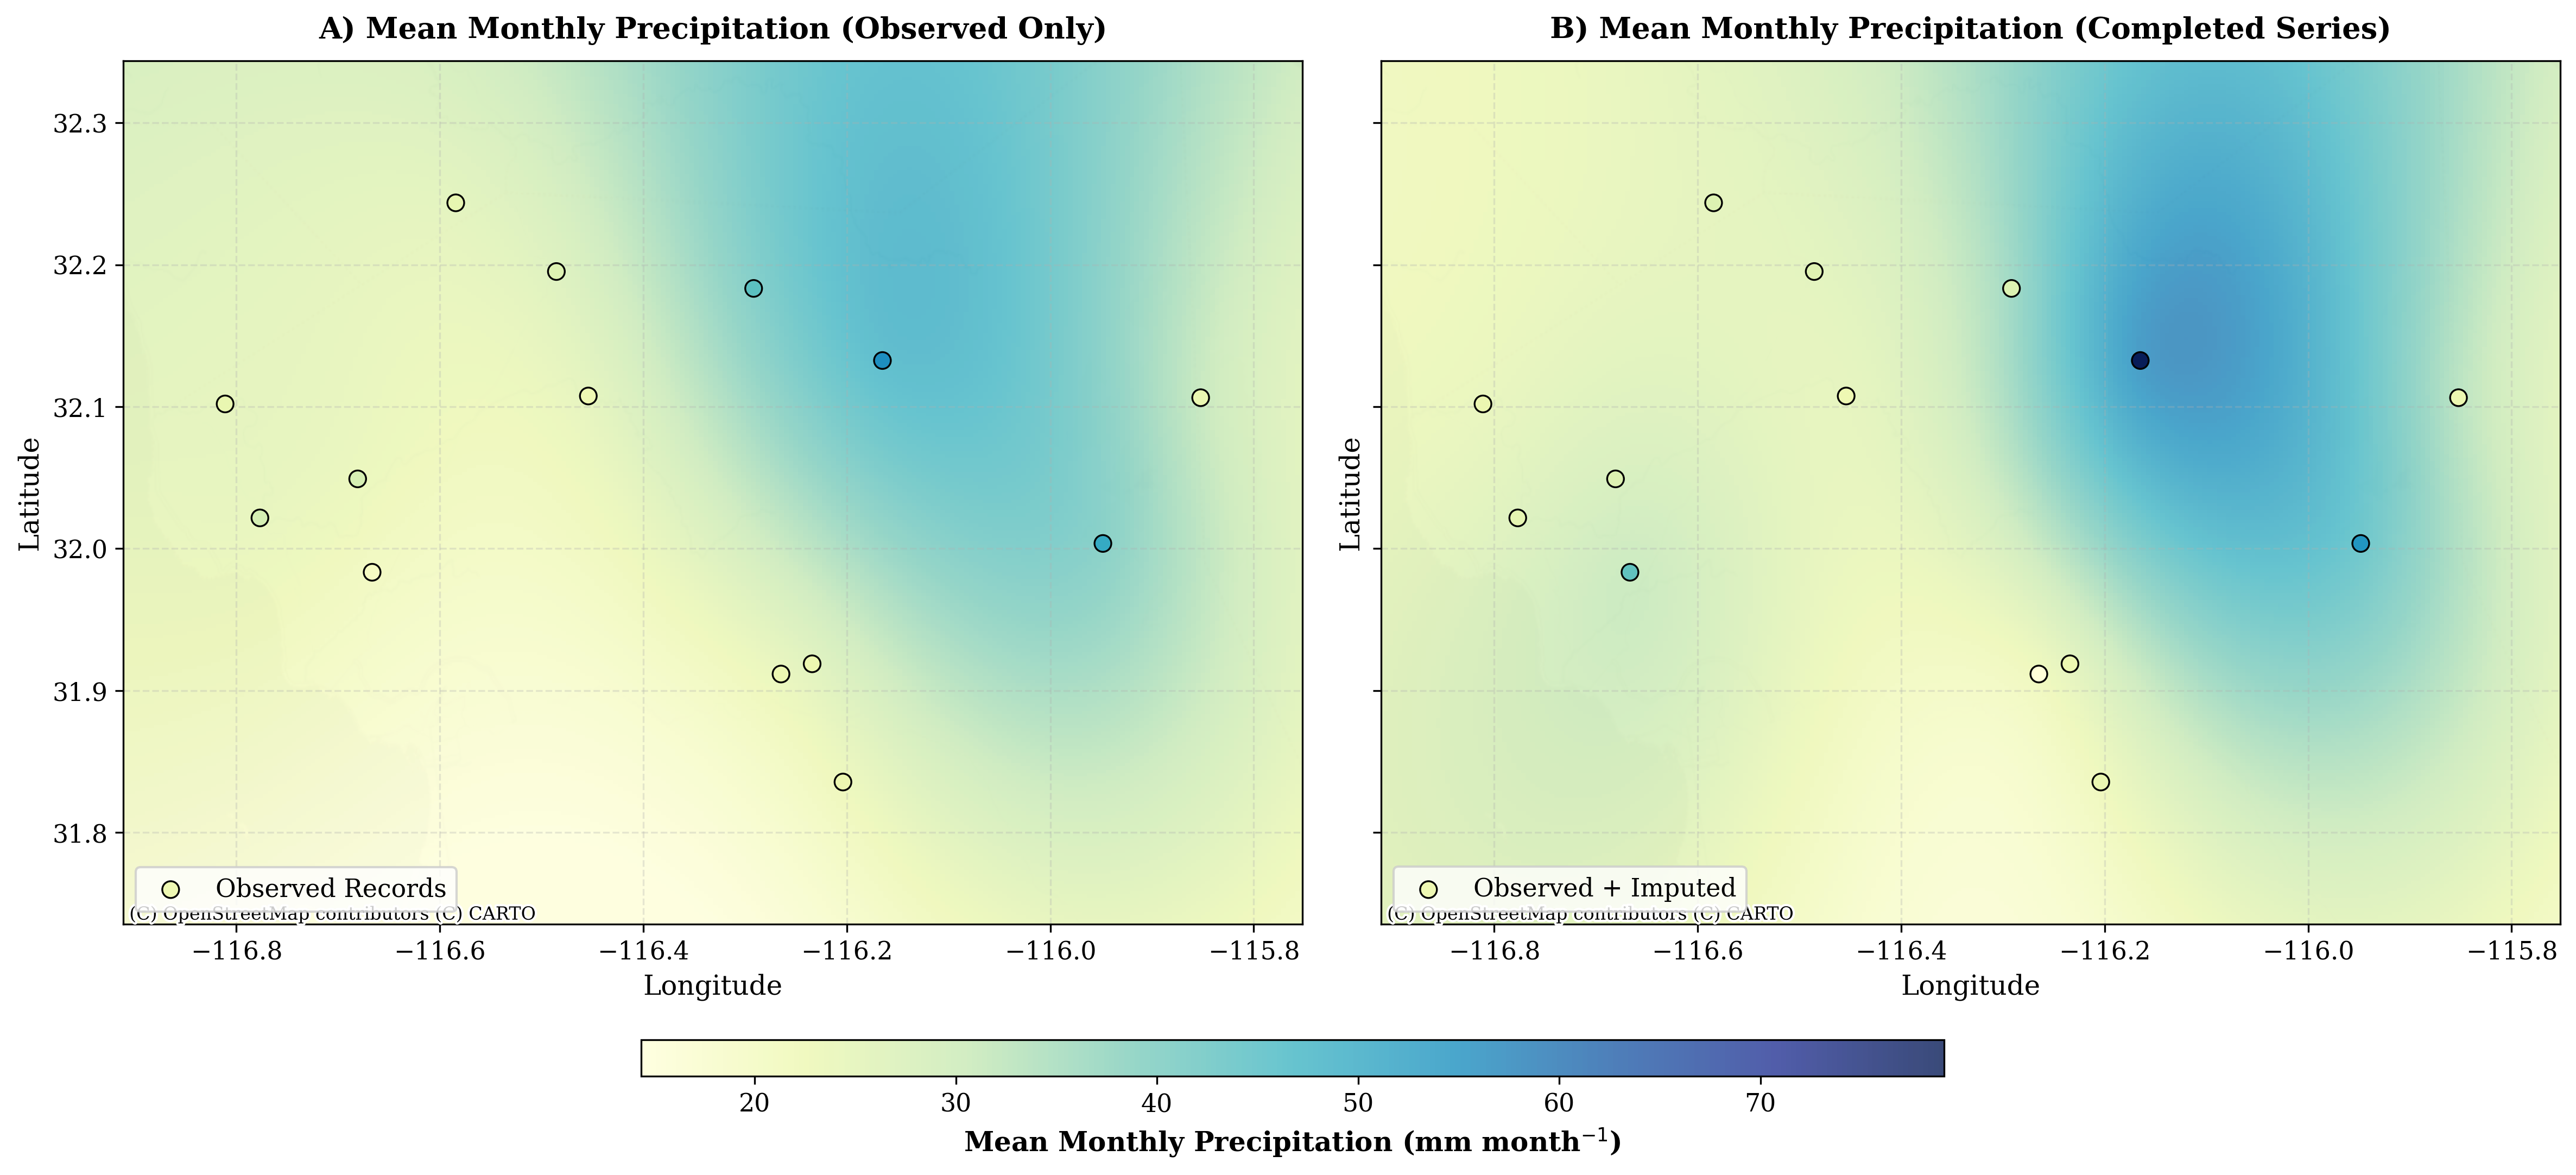

In [13]:
grid_resolution=250

df_gauges=pd.read_csv('rain_gauges_mm.csv')
df_imputed=pd.read_csv('Gualadupe_River_Basin_Imputed_Final.csv')
df_total=pd.merge(df_imputed,df_gauges,on='Station',how='inner')

df_real_only=df_total[df_total['Imputed']==False].copy()

summary_real=df_real_only.groupby(['Station','Lon','Lat'])['Precipitation'].mean().reset_index()
summary_imputed=df_total.groupby(['Station','Lon','Lat'])['Precipitation'].mean().reset_index()

x_min,x_max=df_gauges['Lon'].min()-0.1,df_gauges['Lon'].max()+0.1
y_min,y_max=df_gauges['Lat'].min()-0.1,df_gauges['Lat'].max()+0.1

grid_x,grid_y=np.meshgrid(
    np.linspace(x_min,x_max,grid_resolution),
    np.linspace(y_min,y_max,grid_resolution)
)

grid_points=np.vstack([grid_x.ravel(),grid_y.ravel()]).T

def interpolate_mean(df_summary):
    coords=df_summary[['Lon','Lat']].values
    values=df_summary['Precipitation'].values
    rbf=RBFInterpolator(coords,values,kernel='thin_plate_spline',smoothing=0.05)
    grid=rbf(grid_points).reshape(grid_x.shape)
    return np.maximum(grid,0)

grid_z_real=interpolate_mean(summary_real)
grid_z_imputed=interpolate_mean(summary_imputed)

all_values=np.concatenate([
    summary_real['Precipitation'].values,
    summary_imputed['Precipitation'].values
])

vmin=all_values.min()
vmax=all_values.max()

plt.rcParams.update({
    'font.family':'serif',
    'font.size':11,
    'axes.labelsize':12,
    'axes.titlesize':13
})

fig,axes=plt.subplots(1,2,figsize=(16,7.5),sharex=True,sharey=True,dpi=300)
cmap_style='YlGnBu'

ax_left=axes[0]
im_l=ax_left.pcolormesh(grid_x,grid_y,grid_z_real,cmap=cmap_style,vmin=vmin,vmax=vmax,shading='auto',alpha=0.8)
ax_left.scatter(summary_real['Lon'],summary_real['Lat'],c=summary_real['Precipitation'],cmap=cmap_style,edgecolor='black',linewidth=0.8,s=55,vmin=vmin,vmax=vmax,zorder=3,label='Observed Records')
ax_left.set_title('A) Mean Monthly Precipitation (Observed Only)',weight='bold',pad=10)
ax_left.legend(loc='lower left',frameon=True,facecolor='white')

ax_right=axes[1]
im_r=ax_right.pcolormesh(grid_x,grid_y,grid_z_imputed,cmap=cmap_style,vmin=vmin,vmax=vmax,shading='auto',alpha=0.8)
ax_right.scatter(summary_imputed['Lon'],summary_imputed['Lat'],c=summary_imputed['Precipitation'],cmap=cmap_style,edgecolor='black',linewidth=0.8,s=55,vmin=vmin,vmax=vmax,zorder=3,label='Observed + Imputed')
ax_right.set_title('B) Mean Monthly Precipitation (Completed Series)',weight='bold',pad=10)
ax_right.legend(loc='lower left',frameon=True,facecolor='white')

for ax in axes:
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_xlim(x_min,x_max)
    ax.set_ylim(y_min,y_max)
    ax.grid(True,linestyle='--',alpha=0.3)
    ctx.add_basemap(ax,crs='EPSG:4326',source=ctx.providers.CartoDB.PositronNoLabels,alpha=0.5)

cbar_ax=fig.add_axes([0.25,0.06,0.5,0.03])
cbar=fig.colorbar(im_l,cax=cbar_ax,orientation='horizontal')
cbar.set_label('Mean Monthly Precipitation (mm month$^{-1}$)',weight='bold')

plt.tight_layout(rect=[0,0.1,1,0.95])
plt.savefig('Guadalupe_Basin_Mean_Monthly_Precipitation.tiff',dpi=300,bbox_inches='tight')
plt.show()